In [3]:
!pip install yfinance

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 44.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 171.7 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15637 sha256=c053a6d6ea744deb913140d078365939fccc70018d4e1afe7c5775163f68442a
  Stored in directory: /home/sagemaker-user/.cache/pip/wheels/42/d6/84/bf57a755f4569494cd00de4bb46ef064874823f4d19c82e960
  Created wheel for peewee: filename=peewee-3.18.2-cp311-cp311-linux_x86_64.whl size=300897 sha256=866ee1386e18e5ad9028ca3e02516a12cafaaee1a11fb1f1130bb929ebb55ff8
  Stored in directory: /home/sagemaker-user/.cache/pip/wheels/28/84/61/758d1bd7b9c9d700158c8642a8aff2a9bf2e1ae69641c40784
Successfully built multitasking peewee


In [8]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [20]:
sp500 = yf.download("^GSPC", start='1990-01-01', end=None, interval='1d', auto_adjust=True)
sp500.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000


In [25]:
sp500.columns = [i for i, j in sp500.columns]

In [26]:
sp500

,Close,High,Low,Open,Volume
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000
...,...,...,...,...,...
2025-09-29,6661.209961,6677.310059,6644.490234,6661.580078,5358760000
2025-09-30,6688.459961,6691.250000,6641.000000,6656.189941,6057210000
2025-10-01,6711.200195,6718.479980,6656.200195,6664.919922,6037950000


In [35]:
sp500['Return'] = sp500['Close'].pct_change()
sp500['Volatility_20d'] = sp500['Return'].rolling(20).std()
sp500['MA50'] = sp500['Close'].rolling(50).mean()
sp500['MA200'] = sp500['Close'].rolling(200).mean()
sp500['MA_diff'] = sp500['MA50'] - sp500['MA200']

sp500

,Close,High,Low,Open,Volume,Return,Volatility_20d,MA50,MA200,MA_diff
Date,,,,,,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000,NaN,NaN,NaN,NaN,NaN
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000,-0.002586,NaN,NaN,NaN,NaN
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000,-0.008613,NaN,NaN,NaN,NaN
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000,-0.009756,NaN,NaN,NaN,NaN
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000,0.004514,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-09-29,6661.209961,6677.310059,6644.490234,6661.580078,5358760000,0.002636,0.004560,6467.057988,6017.954841,449.103147
2025-09-30,6688.459961,6691.250000,6641.000000,6656.189941,6057210000,0.004091,0.004129,6474.715186,6021.222590,453.492595
2025-10-01,6711.200195,6718.479980,6656.200195,6664.919922,6037950000,0.003400,0.004081,6482.746787,6024.357642,458.389146


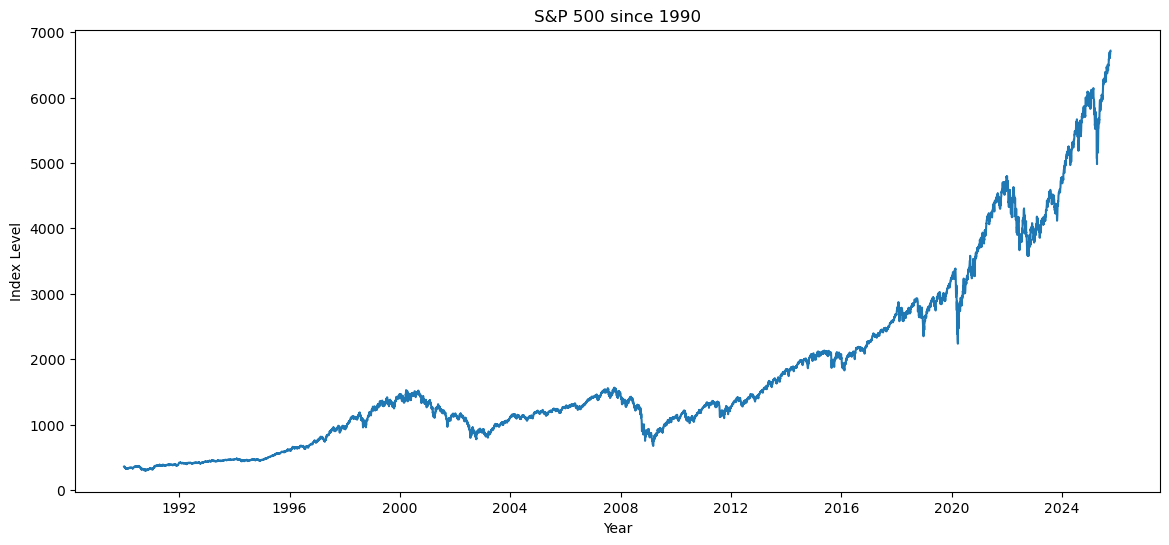

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(sp500.index, sp500['Close'])
plt.title("S&P 500 since 1990")
plt.xlabel('Year')
plt.ylabel('Index Level')
plt.show()

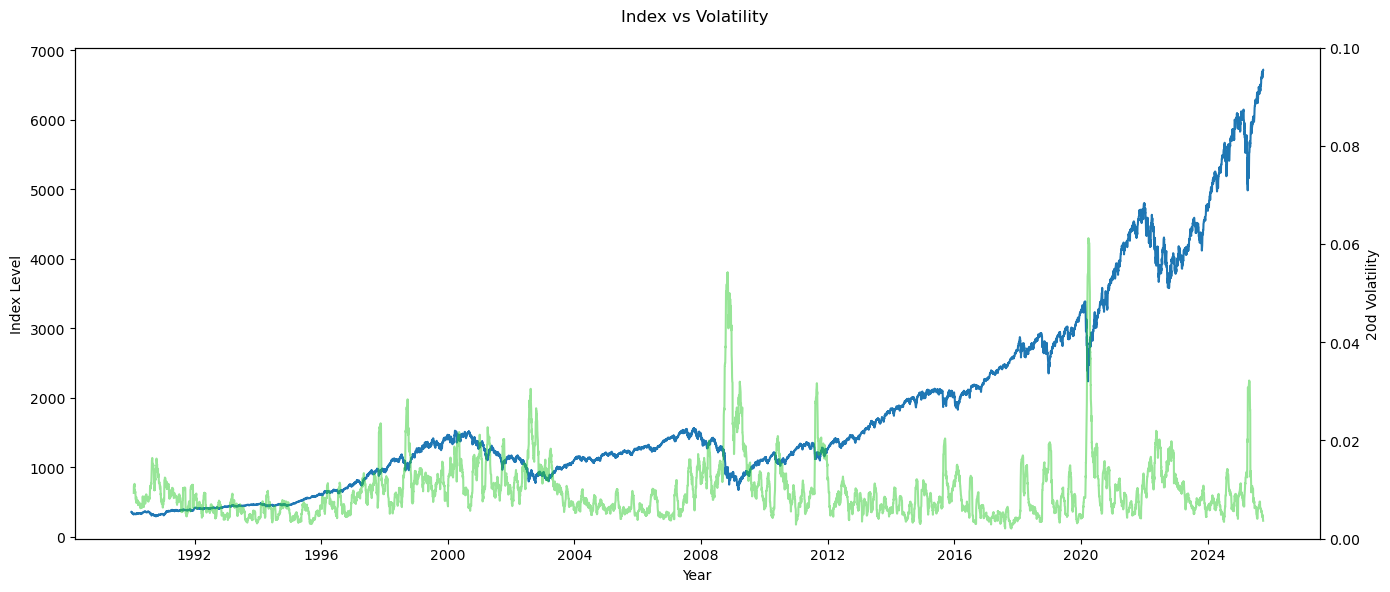

In [34]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('Year')
ax1.set_ylabel('Index Level')
ax1.plot(sp500.index, sp500['Close'], label='Index')

ax2 = ax1.twinx()
ax2.set_ylabel("20d Volatility")
ax2.plot(sp500.index, sp500['Volatility_20d'], label='Volatility', color='limegreen', alpha=0.5)
ax2.set_ylim(0, 0.1)

fig.suptitle("Index vs Volatility")
fig.tight_layout()
plt.show()

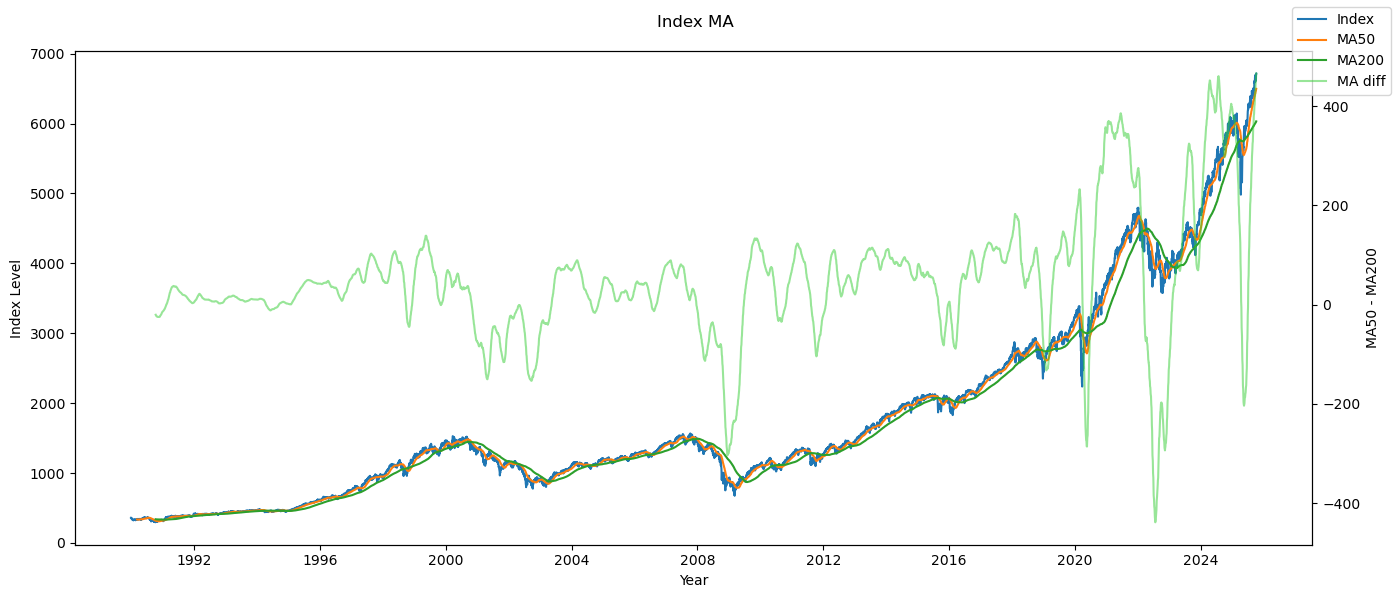

In [38]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.set_xlabel('Year')
ax1.set_ylabel('Index Level')
ax1.plot(sp500.index, sp500['Close'], label='Index')
ax1.plot(sp500.index, sp500['MA50'], label='MA50')
ax1.plot(sp500.index, sp500['MA200'], label='MA200')

ax2 = ax1.twinx()
ax2.set_ylabel("MA50 - MA200")
ax2.plot(sp500.index, sp500['MA_diff'], label='MA diff', color='limegreen', alpha=0.5)
# ax2.set_ylim(0, 0.1)

fig.suptitle("Index MA")
fig.tight_layout()
fig.legend()
plt.show()